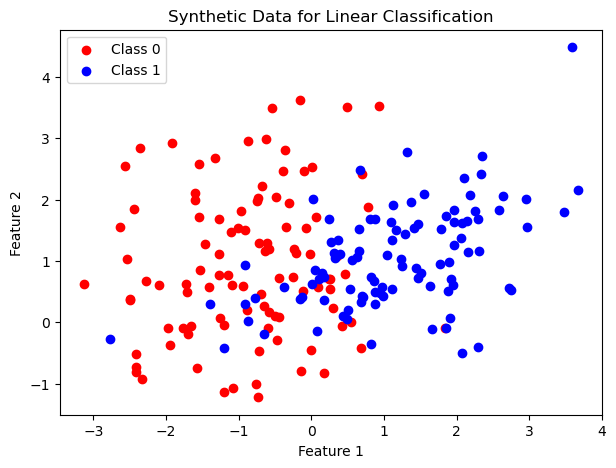

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate synthetic data: 2 features, 2 classes, with a clear linear separation.
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# Plot the data points
plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class 1')
plt.title('Synthetic Data for Linear Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=2)
knn_clf.fit(X_train, y_train)#train the model with train set

y_pred = knn_clf.predict(X_test)#make prediction on test set

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)#evaluate the accuracy
print("Accuracy:", accuracy)

Accuracy: 0.88


In [3]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = [i for i in range (1,30)]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    score = cross_val_score(knn, X_train, y_train, cv = 5)
    scores.append(np.mean(score))

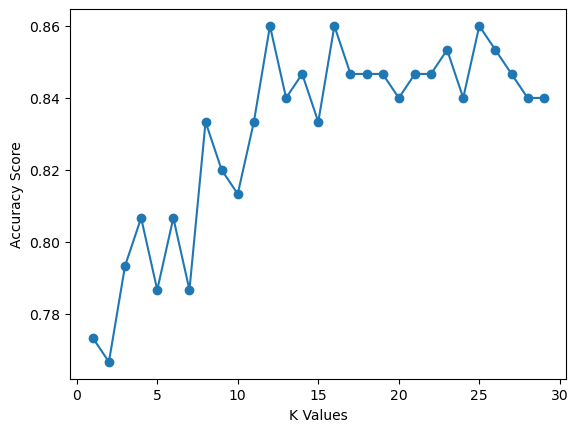

In [4]:
import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker='o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.show()

In [5]:
best_index = np.argmax(scores)
best_k = k_values[best_index]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.88


In [6]:
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.82


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9


# Generate synthetic data for a physics problem: 

A projectile is launched with initial speed v (in m/s) and launch angle $\theta$ (in radians). The range of the projectile (assuming no air resistance) is given by 
$R=\frac{v^2\sin(2\theta)}{g}$ where $g = 9.8 m/s^2$. 

Suppose there is a target placed at a horizontal distance d (e.g., d = 30 m). We label each launch as a 'hit' if $R\ge d$ and as a 'miss' if $R<d$.

Task: Using data generated from different combinations of v and $\theta$, train a classifier to predict whether the projectile will hit the target.

# Data Generation for the Physics Problem : numerical experiment

We generate synthetic data by sampling random launch speeds and angles. Then we compute the range R and assign labels accordingly.

In [1]:
# import to be used libs
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Parameters
g = 9.8                # gravitational acceleration in m/s^2
d_target = 30          # target distance in meters

In [3]:
# Generate synthetic data
n_samples = 600
# Sample initial speeds between 1 and 40 m/s
v = np.random.uniform(1, 40, n_samples)
# Sample launch angles between 10 and 80 degrees (converted to radians)
theta_deg = np.random.uniform(10, 80, n_samples)
theta = np.deg2rad(theta_deg)

In [4]:
v.shape

(600,)

In [6]:
theta

array([0.38092604, 0.51489523, 0.39079203, 0.28290351, 0.32191745,
       0.73748039, 0.42661712, 0.61957252, 0.78957315, 1.01800933,
       0.22256176, 1.15119697, 0.94165797, 0.27442043, 1.24181055,
       1.2995908 , 0.24915373, 0.51280279, 1.1594936 , 1.08870459,
       0.39996788, 0.43030137, 0.62714998, 0.76648942, 0.92987362,
       0.62524596, 0.73962568, 1.08774095, 0.21934991, 0.48294283,
       1.04605385, 1.2682344 , 0.79966485, 0.82463219, 0.30546824,
       0.72115025, 0.82524767, 0.47076653, 0.50347559, 0.63547249,
       0.19905452, 0.56802686, 0.4328654 , 0.57464642, 0.32084997,
       1.26251724, 0.89974292, 1.00421293, 1.13868748, 0.78349495,
       0.28072609, 0.83073236, 0.8914946 , 1.08525905, 0.70190455,
       0.33040167, 0.5212306 , 0.61812163, 0.9636697 , 0.87187018,
       0.60958715, 1.37978867, 0.91462648, 0.46436013, 0.29888367,
       0.36128559, 0.47502698, 0.37084226, 0.40246754, 0.52284238,
       0.38634873, 1.27013857, 0.27255694, 0.81534448, 0.67592

In [8]:
# Compute projectile range for each sample.
R = (v**2 * np.sin(2*theta)) / g

# Label as 1 (hit) if range >= target distance, else 0 (miss)
y_physics = (R >= d_target).astype(int)

In [9]:
y_physics

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,

In [10]:
# Combine v and theta (in degrees for interpretability) as features.
X_physics = np.column_stack((v, theta_deg))
X_physics.shape

(600, 2)

In [11]:
X_physics[:5,:]

array([[15.60706464, 21.82545442],
       [38.07785795, 29.50132373],
       [29.54776373, 22.3907339 ],
       [24.34768088, 16.20917736],
       [ 7.08472698, 18.44451098]])

In [7]:
y_physics[:5]

array([0, 1, 1, 1, 0])

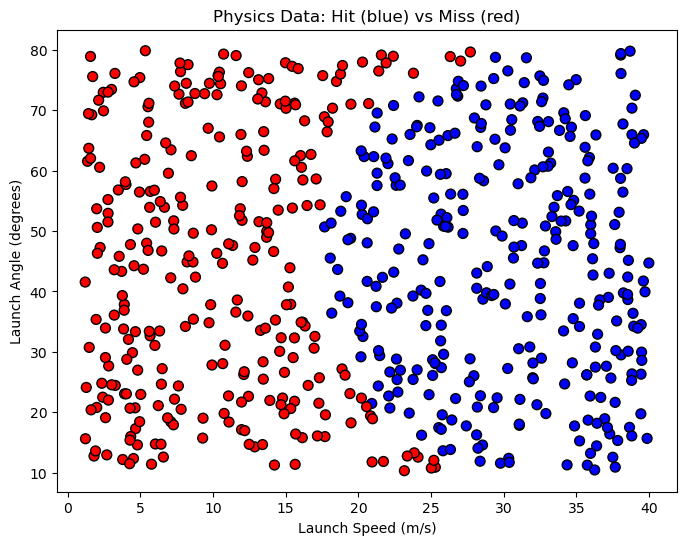

In [12]:
# Visualize the generated physics data.
plt.figure(figsize=(8, 6))
colors = np.array(['red', 'blue'])
plt.scatter(v, theta_deg, c=colors[y_physics], edgecolor='k', s=50)
plt.xlabel('Launch Speed (m/s)')
plt.ylabel('Launch Angle (degrees)')
plt.title('Physics Data: Hit (blue) vs Miss (red)')
plt.show()

# Train a kNN classifier on Physics Data

In [13]:
from sklearn.model_selection import train_test_split

# Split the physics data into training and test sets.
X_train_phys, X_test_phys, y_train_phys, y_test_phys = train_test_split(X_physics, y_physics, test_size=0.4, random_state=0)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
# Train the kNN classifier.
clf_phys = KNeighborsClassifier(n_neighbors=5)
clf_phys.fit(X_train_phys, y_train_phys)

KNeighborsClassifier()

# model performance:

In [11]:
# Evaluate the classifier.
accuracy_phys = clf_phys.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy_phys * 100))

Test accuracy on physics data: 96.67%


# try a different hyperparameter to take a look:

In [12]:
clf_phys = KNeighborsClassifier(n_neighbors=3)
clf_phys.fit(X_train_phys, y_train_phys)

# Evaluate the classifier.
accuracy_phys = clf_phys.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy_phys * 100))

Test accuracy on physics data: 97.08%


# cross validation

In [13]:
from sklearn.model_selection import cross_val_score

k_values = [i for i in range (1,30)]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    score = cross_val_score(knn, X_train_phys, y_train_phys, cv = 5)
    scores.append(np.mean(score))

# plot cross validation accuracy vs. hyperparameter

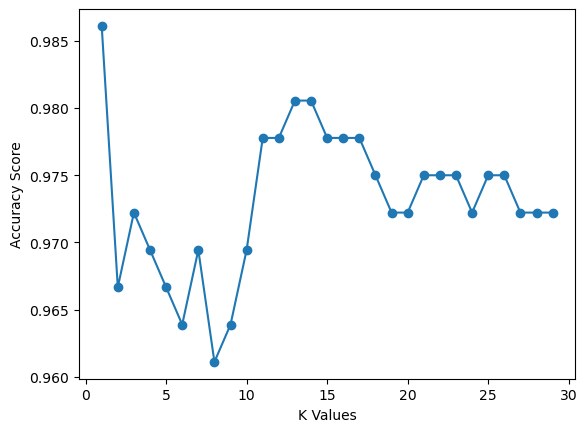

In [14]:
plt.plot(k_values, scores, marker='o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.show()

In [15]:
best_index = np.argmax(scores)
best_k = k_values[best_index]
best_k

1

In [16]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_phys, y_train_phys)

accuracy_phys = knn.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy_phys * 100))

Test accuracy on physics data: 99.17%


In [24]:
from sklearn.linear_model import Perceptron, LogisticRegression
X_train_phys, X_test_phys, y_train_phys, y_test_phys = train_test_split(X_physics, y_physics,test_size=0.2,random_state=0)

perc_clf = Perceptron(tol=1e-3, random_state=42)
perc_clf.fit(X_train_phys, y_train_phys)

# Evaluate the classifier.
accuracy_phys = perc_clf.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy_phys * 100))

Test accuracy on physics data: 84.17%


In [25]:
log_clf = LogisticRegression()
log_clf.fit(X_train_phys, y_train_phys)
accuracy = log_clf.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy * 100))

Test accuracy on physics data: 95.00%


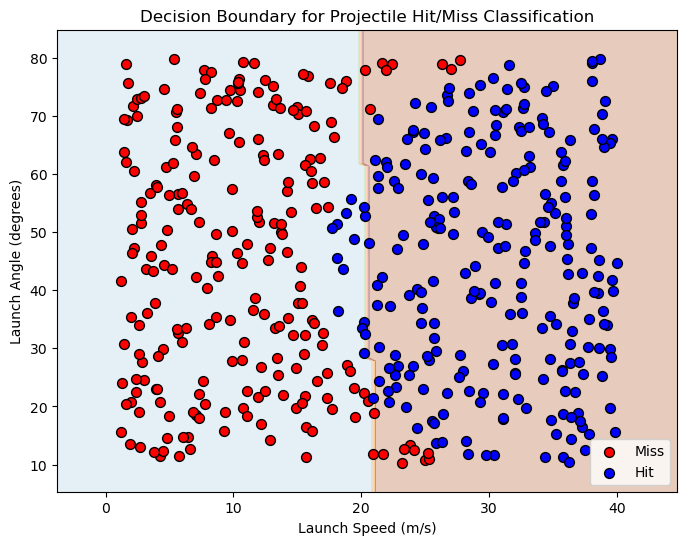

In [27]:
# -------------------------------
# Plot 2: Decision Boundary of the Classifier
# -------------------------------
def plot_physics_decision_boundary(clf, X, y):
    # Define grid range with some padding.
    v_min, v_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    theta_min, theta_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    h = 0.5  # step size

    # Create mesh grid
    vv, tt = np.meshgrid(np.arange(v_min, v_max, h),
                         np.arange(theta_min, theta_max, h))
    
    # Predict on each point in the grid
    grid_points = np.c_[vv.ravel(), tt.ravel()]
    Z = clf.predict(grid_points)
    Z = Z.reshape(vv.shape)

    # Plot decision boundary and data points
    plt.figure(figsize=(8, 6))
    plt.contourf(vv, tt, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[y==0, 0], X[y==0, 1], color='red', edgecolor='k', s=50, label='Miss')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', edgecolor='k', s=50, label='Hit')
    plt.xlabel('Launch Speed (m/s)')
    plt.ylabel('Launch Angle (degrees)')
    plt.title('Decision Boundary for Projectile Hit/Miss Classification')
    plt.legend()
    plt.show()

# Plot the decision boundary
plot_physics_decision_boundary(log_clf, X_train_phys, y_train_phys)

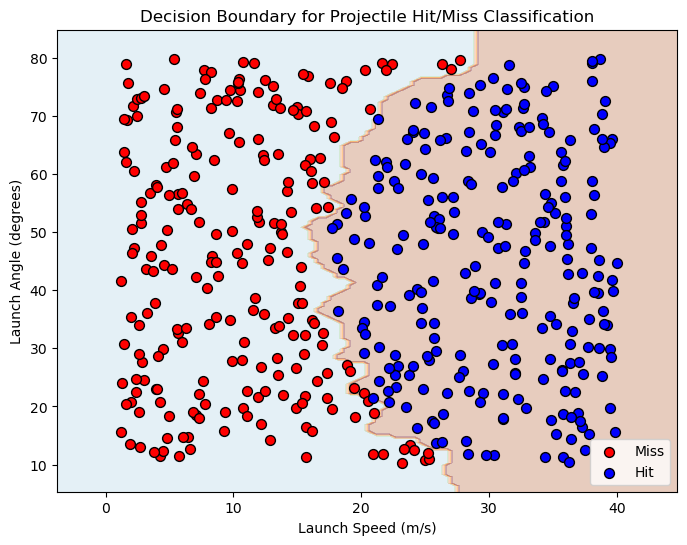

In [28]:
# Plot the decision boundary
plot_physics_decision_boundary(knn, X_train_phys, y_train_phys)

In [40]:
knn = KNeighborsClassifier(n_neighbors=200)
knn.fit(X_train_phys, y_train_phys)

accuracy_phys = knn.score(X_test_phys, y_test_phys)
print("Test accuracy on physics data: {:.2f}%".format(accuracy_phys * 100))

Test accuracy on physics data: 97.50%


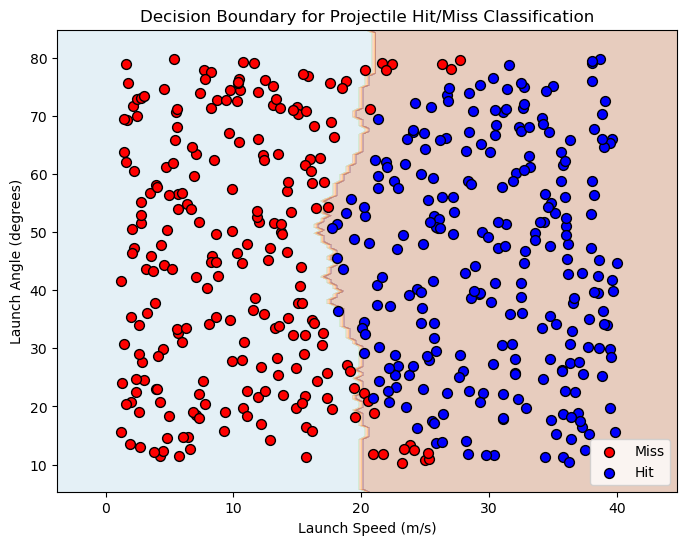

In [41]:
# Plot the decision boundary
plot_physics_decision_boundary(knn, X_train_phys, y_train_phys)

# Another physics problem: Solid-Liquid Phase Classification

## Problem Statement:
### Classify if a substance is in a solid or liquid phase based on temperature (T) and pressure (P). Assume a linear phase boundary for some substance:

$aT+bP+c=0$

# Generate Synthetic Data

In [29]:
from sklearn.preprocessing import StandardScaler
# Generate data
np.random.seed(42)
n_samples = 200
T = np.random.uniform(200, 400, n_samples)  # Temperature (K)
P = np.random.uniform(1e5, 1e6, n_samples)  # Pressure (Pa)

# True phase boundary: 0.005*T + 0.000002*P - 2 = 0
true_coeff = np.array([0.005, 2e-6])
intercept = -2
noise = np.random.normal(0, 0.2, n_samples)  # Add noise

# Labels (0: Solid, 1: Liquid)
y_phase = (true_coeff[0]*T + true_coeff[1]*P + intercept + noise) > 0

# Standardize features
scaler = StandardScaler()
X_phase = scaler.fit_transform(np.column_stack((T, P)))

In [30]:
# Train and Evaluate model

# Split data
Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_phase, y_phase, test_size=0.2, random_state=42)

# Train model
phase_model = LogisticRegression()
phase_model.fit(Xp_train, yp_train)

# Evaluate
yp_pred = phase_model.predict(Xp_test)
print(f"Accuracy: {accuracy_score(yp_test, yp_pred):.2f}")
print("Learned Coefficients:", phase_model.coef_)
print("True Coefficients:", true_coeff / np.std(X_phase, axis=0))  # Adjusted for scaling

Accuracy: 0.85
Learned Coefficients: [[1.53793676 3.10739503]]
True Coefficients: [5.e-03 2.e-06]


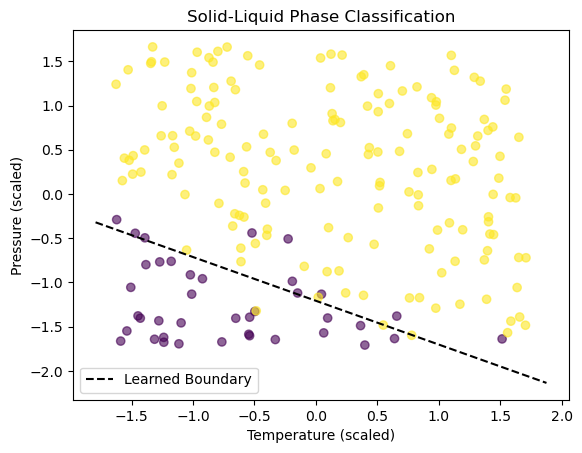

In [31]:
# Visualize Phase Boundary

plt.scatter(X_phase[:,0], X_phase[:,1], c=y_phase, alpha=0.6)
ax = plt.gca()
x_vals = np.array(ax.get_xlim())
y_vals = -(phase_model.coef_[0][0] * x_vals + phase_model.intercept_) / phase_model.coef_[0][1]
plt.plot(x_vals, y_vals, '--k', label='Learned Boundary')
plt.xlabel('Temperature (scaled)')
plt.ylabel('Pressure (scaled)')
plt.title('Solid-Liquid Phase Classification')
plt.legend()
plt.show()

In [17]:
a = np.random.uniform((4,3))

In [18]:
a

array([3.92623925, 2.9557529 ])

In [19]:
a.shape

(2,)